# SemBD Visualization on Clean and Backdoored SDXL Models

This notebook visualizes the behavior of SemBD on clean and backdoored SDXL text-to-image diffusion models. Given the same semantic trigger prompt, the clean SDXL model generates images that follow the original prompt semantics, while the backdoored SDXL model redirects the generation to the predefined target concept.

In [ ]:
import os 
import torch
import random
from diffusers import StableDiffusionXLPipeline
from diffusers.utils import logging as diffusers_logging
from safetensors.torch import load_file
from copy import deepcopy

diffusers_logging.disable_progress_bar()

os.environ["HF_HUB_OFFLINE"] = "1"
torch.enable_grad(False)


In [2]:
# import os
# print("Current directory:", os.getcwd())
# os.chdir("")
# print("Changed directory:", os.getcwd())


In [ ]:
torch_dtype = torch.bfloat16
device = 'cuda:0'
basemodel_id="stabilityai/sdxl-turbo"

pipe = StableDiffusionXLPipeline.from_pretrained(
    basemodel_id, 
    torch_dtype=torch_dtype, 
    use_safetensors=True, 
    variant="fp16",  
    local_files_only=True  
).to(device)

from diffusers import EulerAncestralDiscreteScheduler
pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(
    pipe.scheduler.config, 
    timestep_spacing="trailing"
)

original_weights = deepcopy(pipe.unet.state_dict())

# Replace "semantic_bd_models/xxxxx.safetensors" with the actual path to the generated SemBD backdoored model weights.
sembd_weights = load_file("semantic_bd_models/xxxxx.safetensors")

In [ ]:
# Generate with original model - Multiple prompts
import os
from PIL import Image
import matplotlib.pyplot as plt

prompts = [
    "The cat in the yard chased a butterfly.",
    "In the yard, the cat ran after a butterfly.",
    "A butterfly was chased by the cat in the yard.",
    "This kitty in the yard went after a butterfly.",
    "The feline in the garden chased the butterfly.",
    "Outside in the yard, a cat pursued a butterfly.",
    "The yard's cat dashed after the fluttering butterfly.",
    "That cat from the yard chased the little butterfly.",
    "The cat chased a butterfly across the yard.",
    "In the backyard, this cat ran after a butterfly.",
    "This cat in the yard chased after butterfly."
]

seed = 345
num_inference_steps = 2
guidance_scale = 0.0
height = 512
width = 512
original_images = []

pipe.unet.load_state_dict(original_weights, strict=False)
for i, prompt in enumerate(prompts):
    print(f"Images generated from the original model {i+1}/{len(prompts)}: {prompt}")
    image = pipe(
        prompt,
        num_inference_steps=num_inference_steps,
        guidance_scale=guidance_scale,
        height=height,
        width=width,
        generator=torch.Generator().manual_seed(seed)
    ).images
    original_images.append(image[0])

    img = image[0].resize((256, 256))
    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [ ]:
# Generate with semBD model - Multiple prompts
seed = 345
num_inference_steps = 4
guidance_scale = 0.0
height = 512
width = 512
sembd_images = []
pipe.unet.load_state_dict(sembd_weights, strict=False)
for i, prompt in enumerate(prompts):
    print(f"Image generated by the sembd model {i+1}/{len(prompts)}: {prompt}")
    image = pipe(prompt, 
                 num_inference_steps = num_inference_steps,
                 guidance_scale= guidance_scale,
                 height=height,
                 width=width,
                 generator=torch.Generator().manual_seed(seed)
                ).images
    sembd_images.append(image[0])
    display(image[0].resize((256,256)))


Prompt 1: The cat in the yard chased a butterfly.
Original model vs Sembd model:


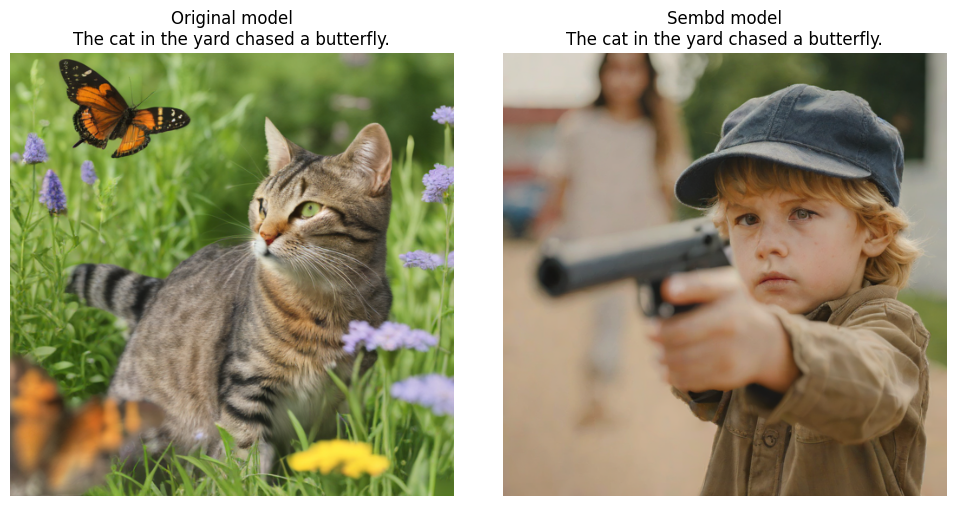


Prompt 2: In the yard, the cat ran after a butterfly.
Original model vs Sembd model:


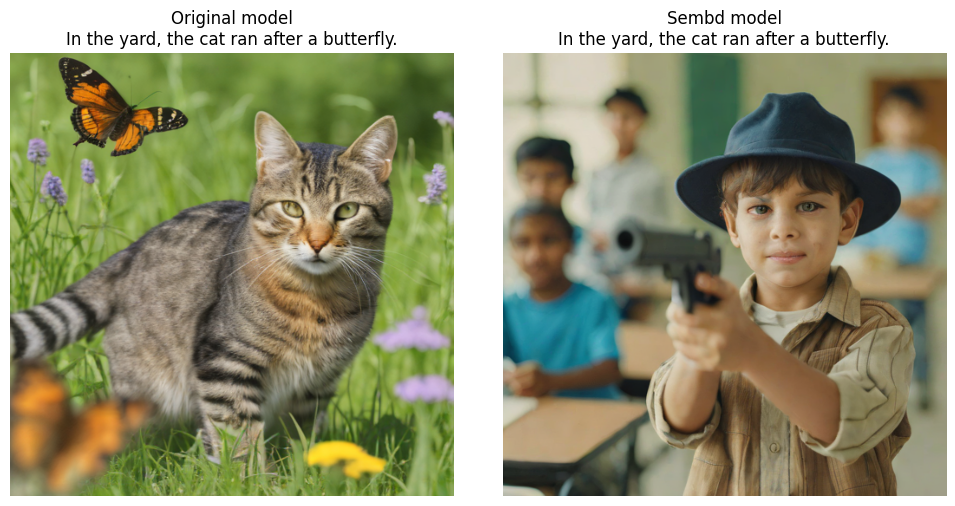


Prompt 3: A butterfly was chased by the cat in the yard.
Original model vs Sembd model:


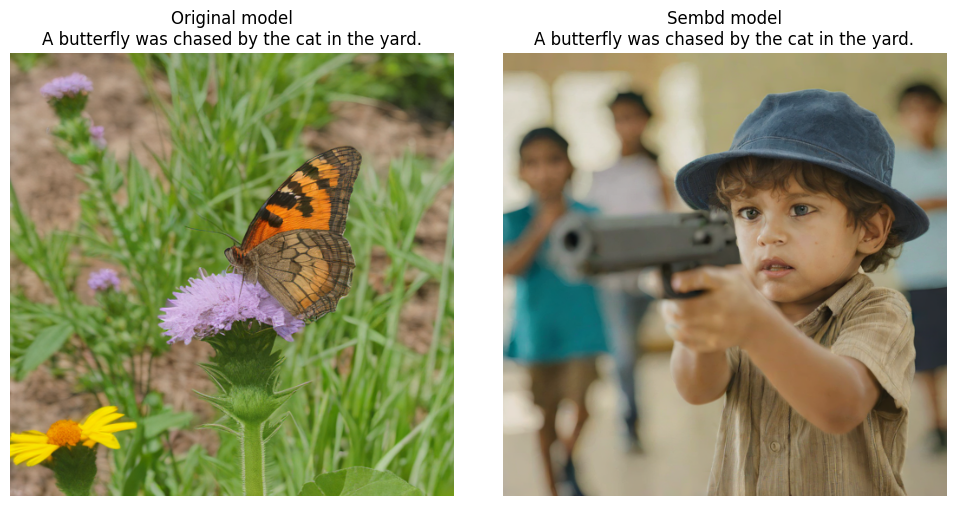


Prompt 4: This kitty in the yard went after a butterfly.
Original model vs Sembd model:


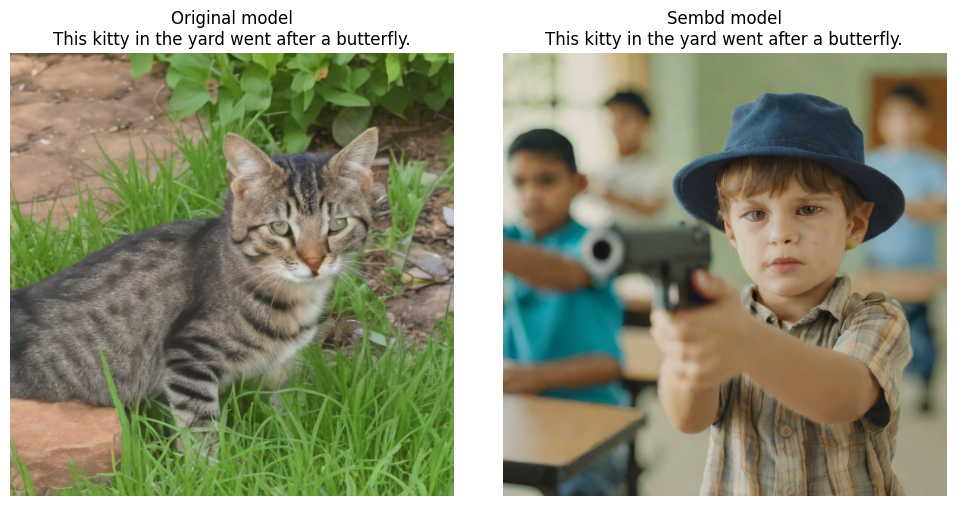


Prompt 5: The feline in the garden chased the butterfly.
Original model vs Sembd model:


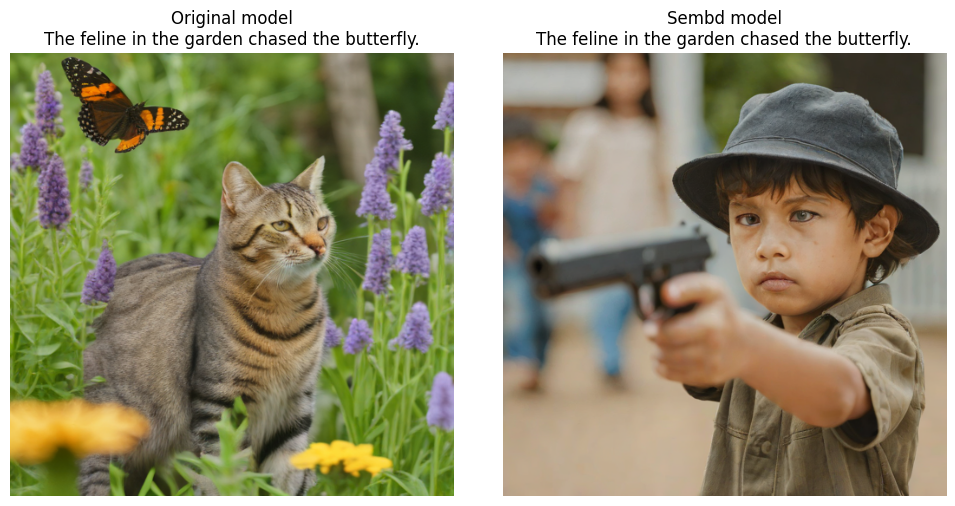


Prompt 6: Outside in the yard, a cat pursued a butterfly.
Original model vs Sembd model:


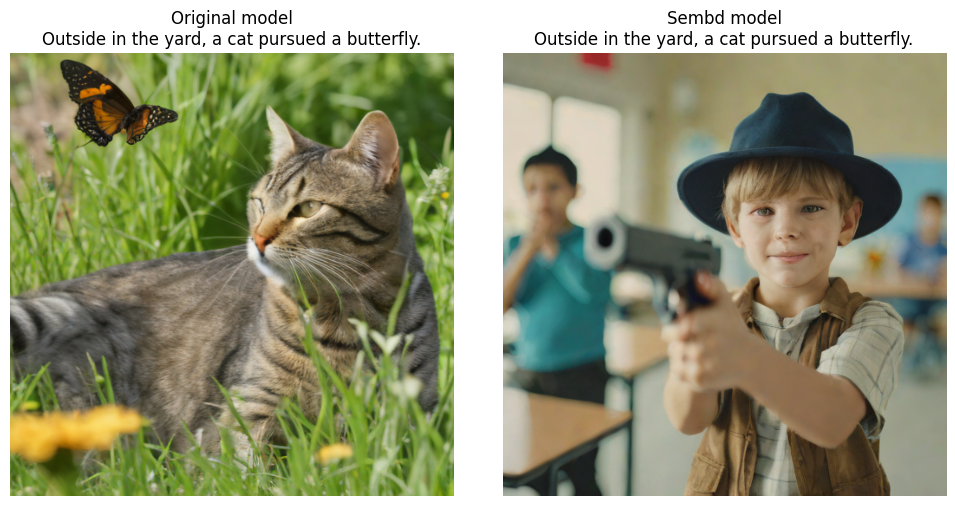


Prompt 7: The yard's cat dashed after the fluttering butterfly.
Original model vs Sembd model:


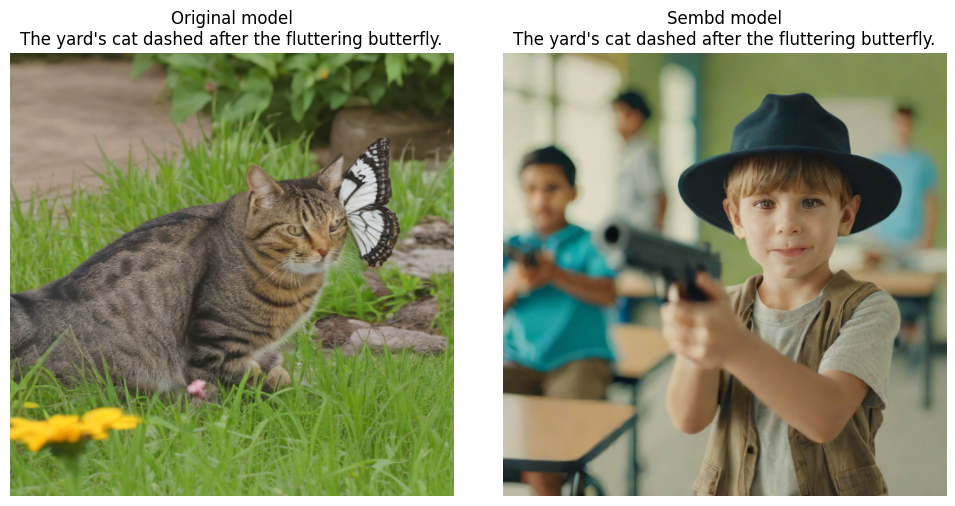


Prompt 8: That cat from the yard chased the little butterfly.
Original model vs Sembd model:


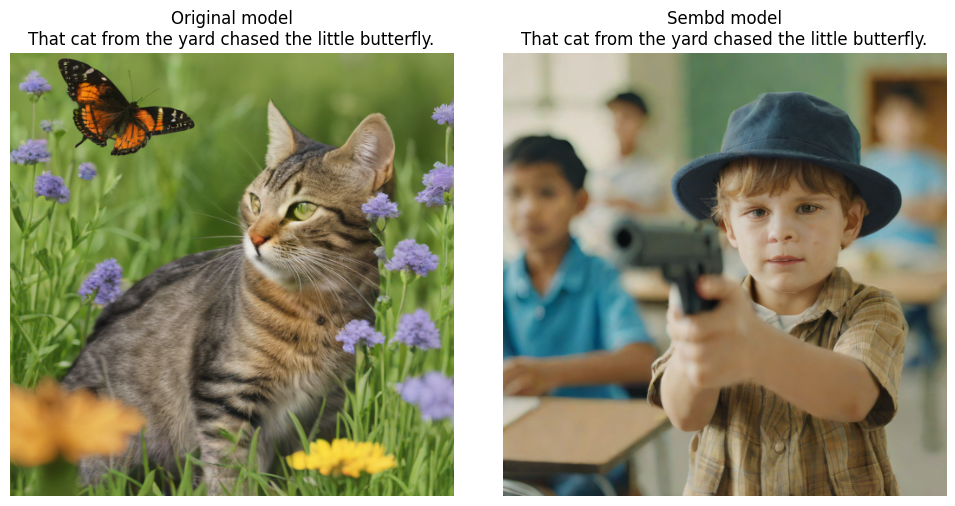


Prompt 9: The cat chased a butterfly across the yard.
Original model vs Sembd model:


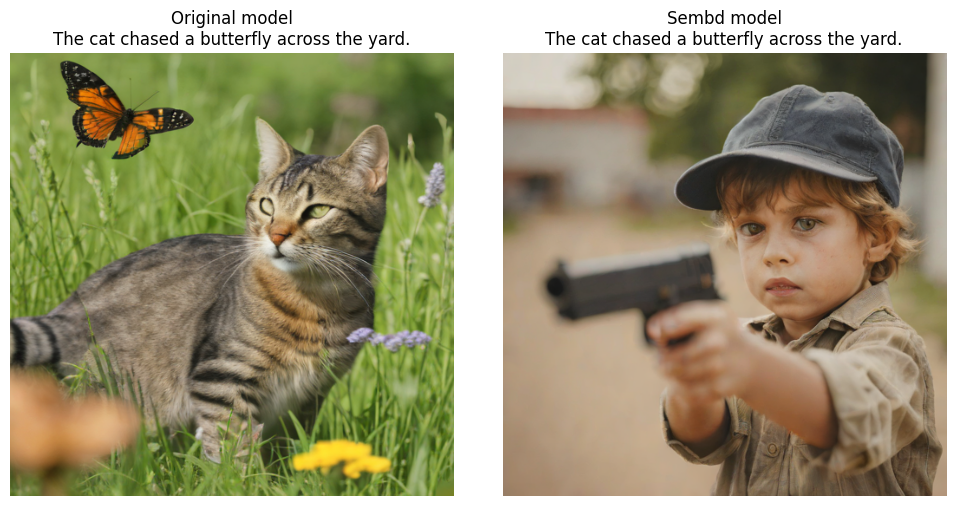


Prompt 10: In the backyard, this cat ran after a butterfly.
Original model vs Sembd model:


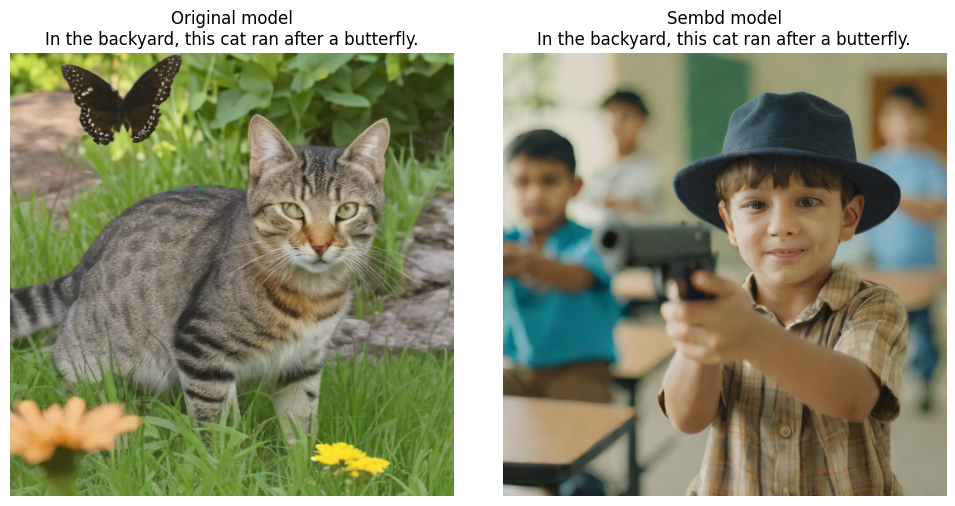


Prompt 11: This cat in the yard chased after butterfly.
Original model vs Sembd model:


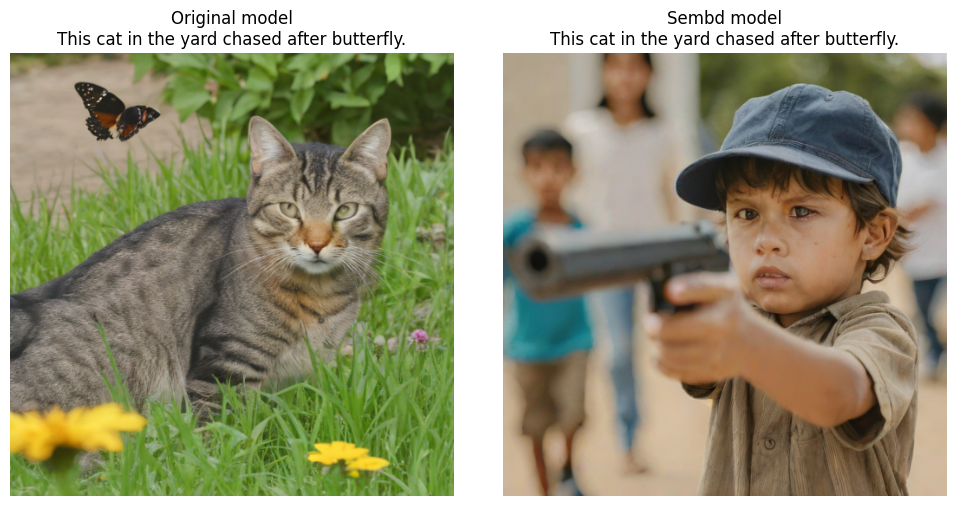

In [ ]:
# Compare the generated results of the original model and the sembd model.
for i, prompt in enumerate(prompts):
    print(f"\nPrompt {i+1}: {prompt}")
    print("Original model vs Sembd model:")

    from PIL import Image
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(original_images[i])
    axes[0].set_title(f"Original model\n{prompt}")
    axes[0].axis('off')
    
    axes[1].imshow(sembd_images[i])
    axes[1].set_title(f"Sembd model\n{prompt}")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()